Opening raw data file /Users/aleksandraszymanska/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 19821 samples (33.001 s)

Fitting ICA to data using 59 channels (please be patient, this may

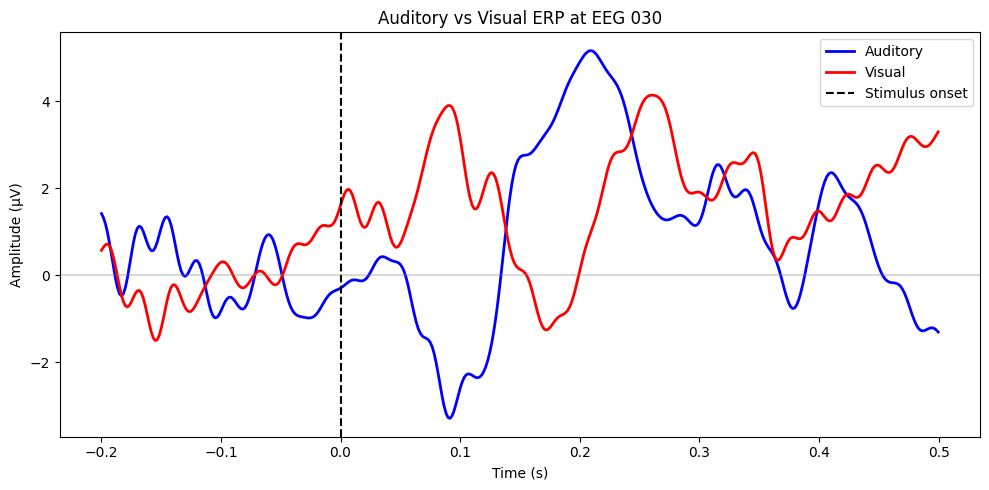

Effective window size : 3.410 (s)
Saved: ../figures/band_power.png


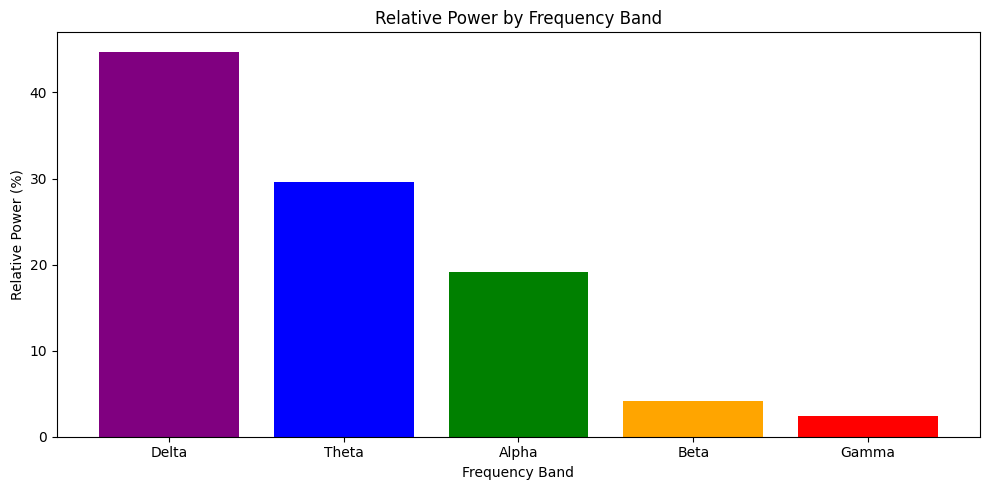

Effective window size : 3.410 (s)


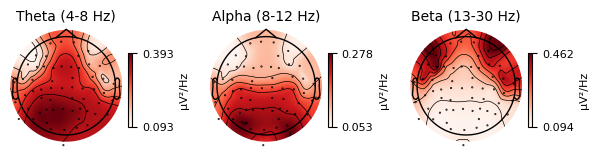

Saved: ../figures/topomap.png

✅ All figures saved to figures/ folder!


In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

# Load and preprocess data
data_path = mne.datasets.sample.data_path()
raw_fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fif_path, preload=True)
raw.pick('eeg')
raw.filter(l_freq=0.1, h_freq=40.0)
ica = ICA(n_components=15, random_state=42)
ica.fit(raw)
ica.exclude = [0]
raw = ica.apply(raw)

# Load events
events_path = data_path / "MEG" / "sample" / "sample_audvis_raw-eve.fif"
events = mne.read_events(events_path)
event_id = {'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}

# Create epochs
epochs = mne.Epochs(raw, events, event_id=event_id, tmin=-0.2, tmax=0.5, baseline=(None, 0), preload=True)

print("Setup complete!")

# Figure 1: ERP Comparison (Auditory vs Visual)
erp_auditory = epochs['auditory/left', 'auditory/right'].average()
erp_visual = epochs['visual/left', 'visual/right'].average()
channel = 'EEG 030'

fig1, ax = plt.subplots(figsize=(10, 5))
times = erp_auditory.times
aud_data = erp_auditory.copy().pick([channel]).get_data()[0] * 1e6
vis_data = erp_visual.copy().pick([channel]).get_data()[0] * 1e6

ax.plot(times, aud_data, label='Auditory', color='blue', linewidth=2)
ax.plot(times, vis_data, label='Visual', color='red', linewidth=2)
ax.axvline(0, color='black', linestyle='--', label='Stimulus onset')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Auditory vs Visual ERP at {channel}')
ax.legend()
plt.tight_layout()
fig1.savefig('../figures/erp_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: ../figures/erp_comparison.png")
plt.show()

# Figure 2: Band Power
bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 12), 'Beta': (13, 30), 'Gamma': (30, 40)}
spectrum = raw.compute_psd(fmin=0.5, fmax=40)
psds, freqs = spectrum.get_data(return_freqs=True)

band_power = {}
for band_name, (fmin, fmax) in bands.items():
    idx = (freqs >= fmin) & (freqs <= fmax)
    band_power[band_name] = psds[:, idx].mean() * 1e12

total_power = sum(band_power.values())
relative_power = {band: (power/total_power)*100 for band, power in band_power.items()}

fig2, ax = plt.subplots(figsize=(10, 5))
colors = ['purple', 'blue', 'green', 'orange', 'red']
ax.bar(relative_power.keys(), relative_power.values(), color=colors)
ax.set_ylabel('Relative Power (%)')
ax.set_xlabel('Frequency Band')
ax.set_title('Relative Power by Frequency Band')
plt.tight_layout()
fig2.savefig('../figures/band_power.png', dpi=300, bbox_inches='tight')
print("Saved: ../figures/band_power.png")
plt.show()

# Figure 3: Topographic Maps
spectrum = raw.compute_psd(fmin=1, fmax=40)
bands_topo = {'Theta (4-8 Hz)': (4, 8), 'Alpha (8-12 Hz)': (8, 12), 'Beta (13-30 Hz)': (13, 30)}
fig3 = spectrum.plot_topomap(bands=bands_topo, normalize=True)
fig3.savefig('../figures/topomap.png', dpi=300, bbox_inches='tight')
print("Saved: ../figures/topomap.png")
plt.show()

print("\n✅ All figures saved to figures/ folder!")